In [2]:
import torch
import numpy as np
from face_score import FACEScorer
import matplotlib.pyplot as plt

In [3]:
face_scorer = FACEScorer(model_path='/Users/xy/models/gpt2-xl',
                         device='mps')

face_scorer.fft_processor.print_fft_args()

FFTProcessor: method=fft, preprocess=none, value=norm, require_sid=True


/Users/xy/.pyenv/versions/miniconda3-latest/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [4]:
text = '路漫漫其修远兮吾将上下而求索'

nlls = face_scorer.texts_to_nll([text])

  0%|          | 0/1 [00:00<?, ?it/s]/Users/xy/.pyenv/versions/miniconda3-latest/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:2855: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(
100%|██████████| 1/1 [00:00<00:00,  3.27it/s]


In [5]:
print(nlls)

encoded_text = face_scorer.texts_to_encoded([text])
print(encoded_text)

ids = face_scorer.tokenizer.encode(text)
print(ids)

print(f'nlls shape: {nlls[0].shape}')
print(f'ids shape: {len(ids)}')

[tensor([3.3446, 0.4198, 3.1363, 4.4743, 2.8842, 2.4120, 2.3318, 2.0042, 4.6326,
        1.2969, 5.6998, 1.4904, 5.1739, 4.4155, 4.8406, 5.8566, 5.3426, 6.4373,
        9.6303, 6.3765, 3.2279, 0.9727, 6.0517, 0.1506, 2.4043, 4.8816, 0.1152,
        3.4832, 4.2101, 2.5825], device='mps:0')]
{'input_ids': tensor([[  164,   115,   107,   162,   120,   104,   162,   120,   104, 17739,
           114, 46479,   106, 32573,   250, 17739,   106, 28938,   122, 49546,
         41468, 10310,   233, 32003,   234,   162,   109,   224,   163,   112,
            95]], device='mps:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1]], device='mps:0')}
[164, 115, 107, 162, 120, 104, 162, 120, 104, 17739, 114, 46479, 106, 32573, 250, 17739, 106, 28938, 122, 49546, 41468, 10310, 233, 32003, 234, 162, 109, 224, 163, 112, 95]
nlls shape: torch.Size([30])
ids shape: 31


In [ ]:
face_scorer.tokenizer.decode(ids)

encoded_text = face_scorer.tokenizer(text)
for i in range(len(encoded_text['input_ids'])):
    print(encoded_text.token_to_chars(i))
    charspan = encoded_text.token_to_chars(i)
    start = charspan[0]
    end = charspan[1]
    print(text[start:end])

# print(type(encoded_text))

In [86]:
print(face_scorer.tokenizer.decode(ids[:3]))
print(face_scorer.tokenizer.decode(ids[3:9]))

路
漫漫


In [7]:
from typing import List, Tuple, Union

def decode_zh(text, encoded) -> Tuple[List[str], List[Tuple]]:
    CJK_UNI_START = 0x4E00
    CJK_UNI_END = 0x9FFF
    characters, token_spans = [], []

    prev_charspan_end = None
    for i in range(len(encoded['input_ids'])):
        charspan = encoded.token_to_chars(i)
        if i == 0:
            prev_charspan_end = charspan[1]
            characters.append(text[charspan[0]:charspan[1]])
            token_spans.append((0, i+1))
        else:
            if charspan[0] == prev_charspan_end:
                characters.append(text[charspan[0]:charspan[1]])
                token_spans.append((i, i+1))
                prev_charspan_end = charspan[1]
            else:
                old = token_spans[-1]
                token_spans[-1] = (old[0], i+1)
    
    return characters, token_spans

In [8]:
chars, spans = decode_zh(text, encoded_text)

print(chars)
print(f'spans len: {len(spans)}', spans)

['路', '漫', '漫', '其', '修', '远', '兮', '吾', '将', '上', '下', '而', '求', '索']
spans len: 14 [(0, 3), (3, 6), (6, 9), (9, 11), (11, 13), (13, 15), (15, 17), (17, 19), (19, 20), (20, 21), (21, 23), (23, 25), (25, 28), (28, 31)]


In [9]:
def spans_to_nlls(nlls: torch.Tensor, spans, reduce='sum'):
    nlls_reduced = []
    for span in spans:
        if reduce == 'sum':
            nlls_reduced.append(nlls[span[0]:span[1]].sum().item())
        elif reduce == 'mean':
            nlls_reduced.append(nlls[span[0]:span[1]].mean().item())
    return nlls_reduced

In [10]:
nlls_zh = spans_to_nlls(nlls[0], spans, reduce='sum')
print(nlls_zh)
print(len(nlls_zh))

[6.900681495666504, 9.770546913146973, 8.968652725219727, 6.996628761291504, 6.664273262023926, 9.256078720092773, 11.199214935302734, 16.067636489868164, 6.376474857330322, 3.2279212474823, 7.024370193481445, 2.554910898208618, 8.480058670043945, 6.792625427246094]
14


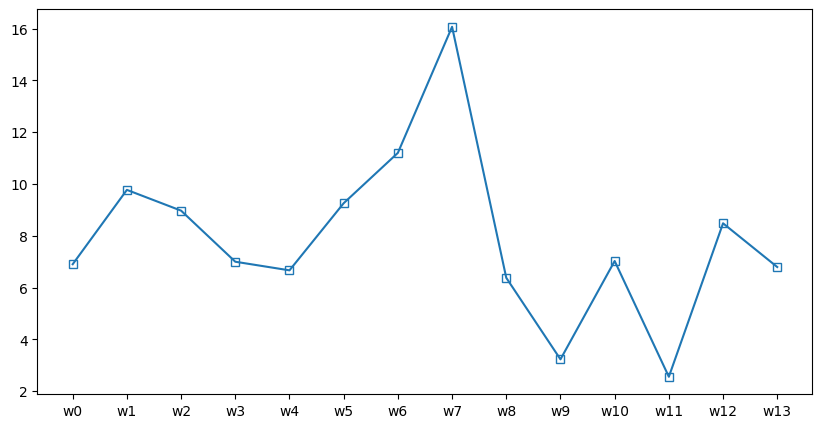

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

x = [f'w{i}' for i in range(len(nlls_zh))]
ax.plot(x, nlls_zh, marker='s', fillstyle='none')

# save figure
plt.savefig('lisao_nlls.svg')

In [13]:
fft = face_scorer.nll_to_spectrum([nlls_zh])
print(fft)

([array([110.2800746 ,  14.7547311 ,  17.32098362,  13.4093077 ,
         4.27654663,  13.45354612,   9.99724007])], [array([0.        , 0.07142857, 0.14285714, 0.21428571, 0.28571429,
       0.35714286, 0.42857143])])


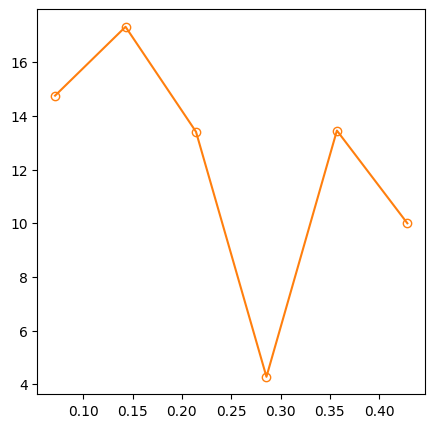

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

freq = fft[1][0]
power = fft[0][0]
ax.plot(freq[1:], power[1:], marker='o', fillstyle='none', color='#ff7f0e')

plt.savefig('lisao_fft.svg')

In [18]:
print(1/0.36)
print(1/0.14)

2.7777777777777777
7.142857142857142


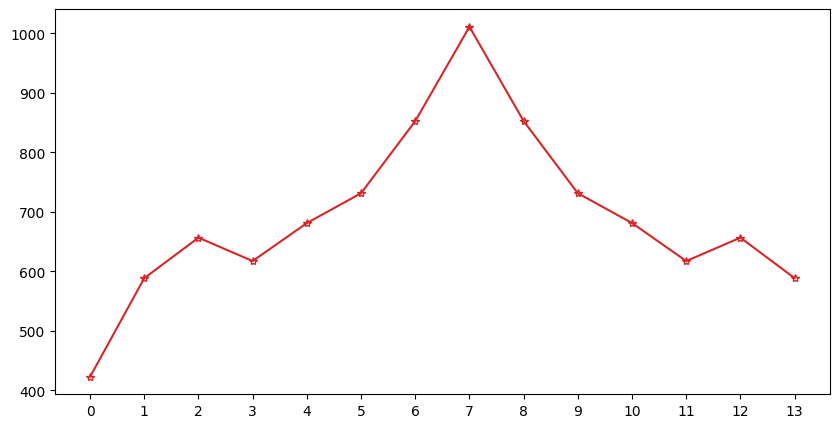

In [17]:
# Get auto correlation
nlls_acf = np.correlate(nlls_zh, nlls_zh, mode='same')

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

x = [f'{i}' for i in range(len(nlls_acf))]
ax.plot(x, nlls_acf, marker='*', fillstyle='none', color='#d62728')

plt.savefig('lisao_acf.svg')